In [58]:

import pandas as pd
df= pd.read_csv("AAPL_2006-01-01_to_2018-01-01.csv")



In [59]:
import matplotlib.pyplot as plt

In [60]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
import numpy as np

In [62]:
import torch

In [63]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   str    
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   str    
dtypes: float64(4), int64(1), str(2)
memory usage: 206.5 KB


In [65]:
df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03
mean,64.673309,65.256833,64.033445,64.662892,1.311457e+08
std,44.524927,44.811772,44.230829,44.536448,1.018560e+08
min,7.390000,7.560000,7.170000,7.240000,1.147592e+07
25%,23.425000,23.805000,23.015000,23.420000,5.292889e+07
50%,57.860000,58.460000,57.320000,57.920000,1.066271e+08
75%,99.165000,100.275000,98.385000,99.480000,1.798977e+08
max,175.110000,177.200000,174.860000,176.420000,8.432640e+08


In [66]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64

In [67]:
close_prices = df["Close"]

close_prices.head()

0    10.68
1    10.71
2    10.63
3    10.90
4    10.86
Name: Close, dtype: float64

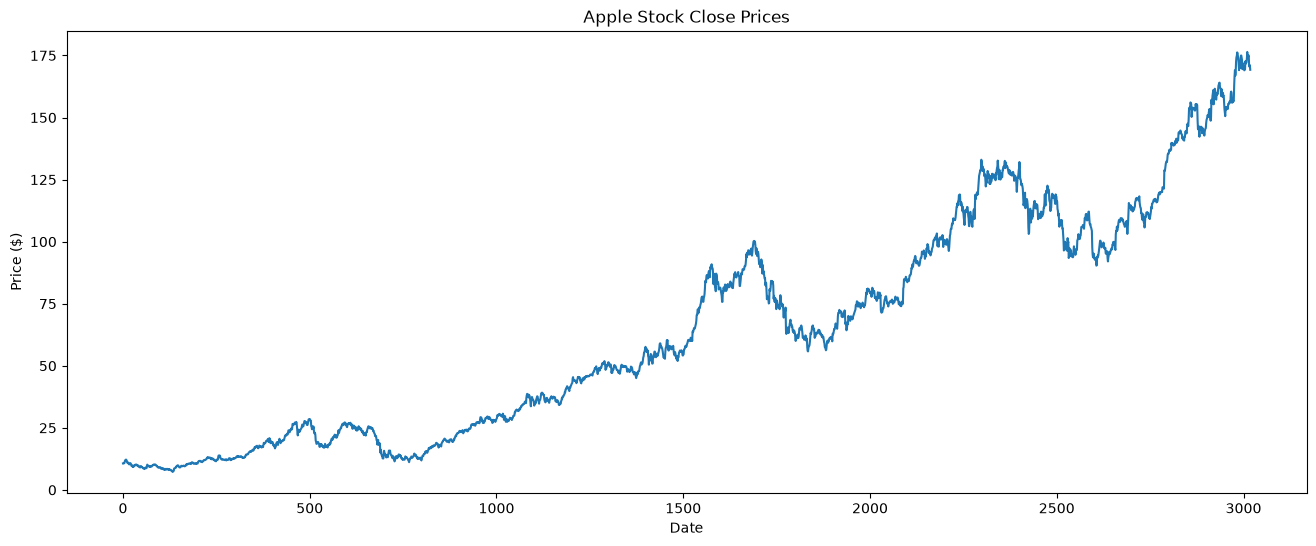

In [68]:
plt.figure(figsize=(16,6))

plt.plot(close_prices)

plt.title("Apple Stock Close Prices")

plt.xlabel("Date")

plt.ylabel("Price ($)")

plt.show()

In [69]:
dataset = close_prices.values

In [70]:
dataset.shape

(3019,)

In [71]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(dataset.reshape(-1,1))

In [72]:
scaled_data[:5]

array([[0.02033337],
       [0.0205107 ],
       [0.02003783],
       [0.02163376],
       [0.02139733]])

In [73]:
training_size = int(len(scaled_data)*0.8)

test_size = len(scaled_data)-training_size

train_data = scaled_data[:training_size]

test_data = scaled_data[training_size:]

In [74]:
def create_dataset(dataset, time_step=20):

    X = []
    y = []

    for i in range(len(dataset)-time_step-1):

        X.append(dataset[i:(i+time_step),0])

        y.append(dataset[i+time_step,0])

    return np.array(X), np.array(y)

In [75]:
time_step = 20

X_train, y_train = create_dataset(train_data, time_step)

X_test, y_test = create_dataset(test_data, time_step)

In [76]:
print(X_train.shape)

print(y_train.shape)

print(X_test.shape)

print(y_test.shape)

(2394, 20)
(2394,)
(583, 20)
(583,)


In [77]:
X_train = torch.tensor(X_train,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)

X_test = torch.tensor(X_test,dtype=torch.float32)

y_test = torch.tensor(y_test,dtype=torch.float32)

In [78]:
X_train = X_train.reshape(X_train.shape[0],20,1)

X_test = X_test.reshape(X_test.shape[0],20,1)

In [79]:
print(X_train.shape)

print(X_test.shape)

torch.Size([2394, 20, 1])
torch.Size([583, 20, 1])


In [80]:
from torch.utils.data import TensorDataset, DataLoader
batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [82]:
import torch.nn as nn
class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):

        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(device)

        c0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(device)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [83]:
model = LSTMModel().to(device)

print(model)

LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [84]:
criterion = nn.MSELoss()

In [85]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [86]:
epochs = 50

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs.squeeze(), labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.6f}")

Epoch [1/50] Loss: 0.044127
Epoch [2/50] Loss: 0.004221
Epoch [3/50] Loss: 0.000508
Epoch [4/50] Loss: 0.000232
Epoch [5/50] Loss: 0.000216
Epoch [6/50] Loss: 0.000212
Epoch [7/50] Loss: 0.000199
Epoch [8/50] Loss: 0.000194
Epoch [9/50] Loss: 0.000204
Epoch [10/50] Loss: 0.000188
Epoch [11/50] Loss: 0.000176
Epoch [12/50] Loss: 0.000194
Epoch [13/50] Loss: 0.000170
Epoch [14/50] Loss: 0.000165
Epoch [15/50] Loss: 0.000174
Epoch [16/50] Loss: 0.000190
Epoch [17/50] Loss: 0.000186
Epoch [18/50] Loss: 0.000159
Epoch [19/50] Loss: 0.000152
Epoch [20/50] Loss: 0.000140
Epoch [21/50] Loss: 0.000156
Epoch [22/50] Loss: 0.000179
Epoch [23/50] Loss: 0.000146
Epoch [24/50] Loss: 0.000139
Epoch [25/50] Loss: 0.000136
Epoch [26/50] Loss: 0.000156
Epoch [27/50] Loss: 0.000142
Epoch [28/50] Loss: 0.000125
Epoch [29/50] Loss: 0.000144
Epoch [30/50] Loss: 0.000136
Epoch [31/50] Loss: 0.000131
Epoch [32/50] Loss: 0.000124
Epoch [33/50] Loss: 0.000128
Epoch [34/50] Loss: 0.000114
Epoch [35/50] Loss: 0.0

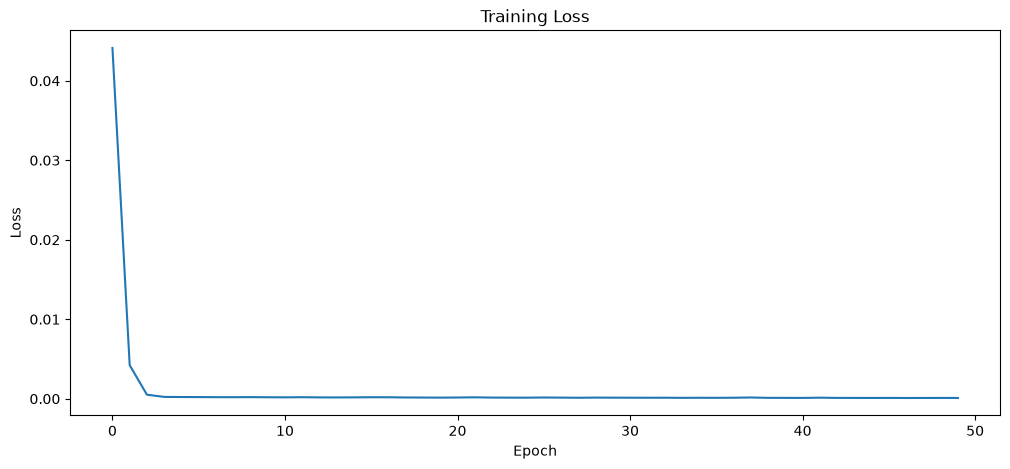

In [87]:
plt.figure(figsize=(12,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [88]:
model.eval()

predictions = []

actuals = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = model(inputs)

        predictions.extend(outputs.cpu().numpy())

        actuals.extend(labels.numpy())

In [89]:
predictions = np.array(predictions)

actuals = np.array(actuals)

In [90]:
predictions = scaler.inverse_transform(predictions)

actuals = scaler.inverse_transform(actuals.reshape(-1,1))

In [91]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(actuals, predictions)

rmse = np.sqrt(mse)

print("MSE :", mse)

print("RMSE:", rmse)

MSE : 15.171350479125977
RMSE: 3.8950417814352103


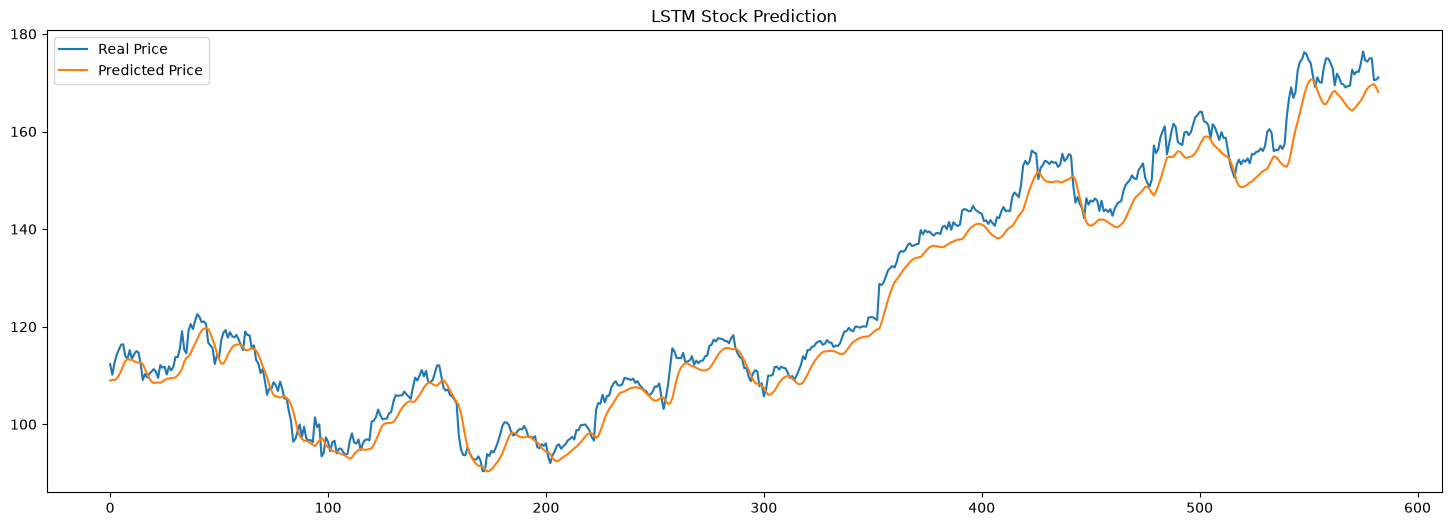

In [92]:
plt.figure(figsize=(18,6))

plt.plot(actuals, label="Real Price")

plt.plot(predictions, label="Predicted Price")

plt.legend()

plt.title("LSTM Stock Prediction")

plt.show()

In [93]:
torch.save(
    model.state_dict(),
    "../models/lstm_model.pth"
)

In [94]:
class GRUModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):

        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(device)

        out, _ = self.gru(x, h0)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [95]:
gru_model = GRUModel().to(device)

print(gru_model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [96]:
criterion = nn.MSELoss()

In [97]:
optimizer = torch.optim.Adam(
    gru_model.parameters(),
    lr=0.001
)

In [98]:
epochs = 50

gru_losses = []

for epoch in range(epochs):

    gru_model.train()

    running_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = gru_model(inputs)

        loss = criterion(outputs.squeeze(), labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    gru_losses.append(epoch_loss)

    print(f"Epoch {epoch+1} Loss : {epoch_loss:.6f}")

Epoch 1 Loss : 0.034772
Epoch 2 Loss : 0.001029
Epoch 3 Loss : 0.000120
Epoch 4 Loss : 0.000096
Epoch 5 Loss : 0.000090
Epoch 6 Loss : 0.000086
Epoch 7 Loss : 0.000083
Epoch 8 Loss : 0.000080
Epoch 9 Loss : 0.000076
Epoch 10 Loss : 0.000073
Epoch 11 Loss : 0.000072
Epoch 12 Loss : 0.000074
Epoch 13 Loss : 0.000070
Epoch 14 Loss : 0.000070
Epoch 15 Loss : 0.000074
Epoch 16 Loss : 0.000071
Epoch 17 Loss : 0.000078
Epoch 18 Loss : 0.000069
Epoch 19 Loss : 0.000064
Epoch 20 Loss : 0.000061
Epoch 21 Loss : 0.000066
Epoch 22 Loss : 0.000070
Epoch 23 Loss : 0.000064
Epoch 24 Loss : 0.000058
Epoch 25 Loss : 0.000060
Epoch 26 Loss : 0.000060
Epoch 27 Loss : 0.000058
Epoch 28 Loss : 0.000060
Epoch 29 Loss : 0.000055
Epoch 30 Loss : 0.000058
Epoch 31 Loss : 0.000058
Epoch 32 Loss : 0.000060
Epoch 33 Loss : 0.000057
Epoch 34 Loss : 0.000055
Epoch 35 Loss : 0.000056
Epoch 36 Loss : 0.000051
Epoch 37 Loss : 0.000058
Epoch 38 Loss : 0.000052
Epoch 39 Loss : 0.000069
Epoch 40 Loss : 0.000055
Epoch 41 

In [99]:
gru_model.eval()

gru_predictions = []

gru_actual = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)

        outputs = gru_model(inputs)

        gru_predictions.extend(outputs.cpu().numpy())

        gru_actual.extend(labels.numpy())

In [100]:
gru_predictions = np.array(gru_predictions)

gru_actual = np.array(gru_actual)

In [101]:
gru_predictions = scaler.inverse_transform(gru_predictions)

gru_actual = scaler.inverse_transform(
    gru_actual.reshape(-1,1)
)

In [102]:
gru_mse = mean_squared_error(
    gru_actual,
    gru_predictions
)

gru_rmse = np.sqrt(gru_mse)

print(gru_mse)

print(gru_rmse)

6.058772563934326
2.4614574064838752


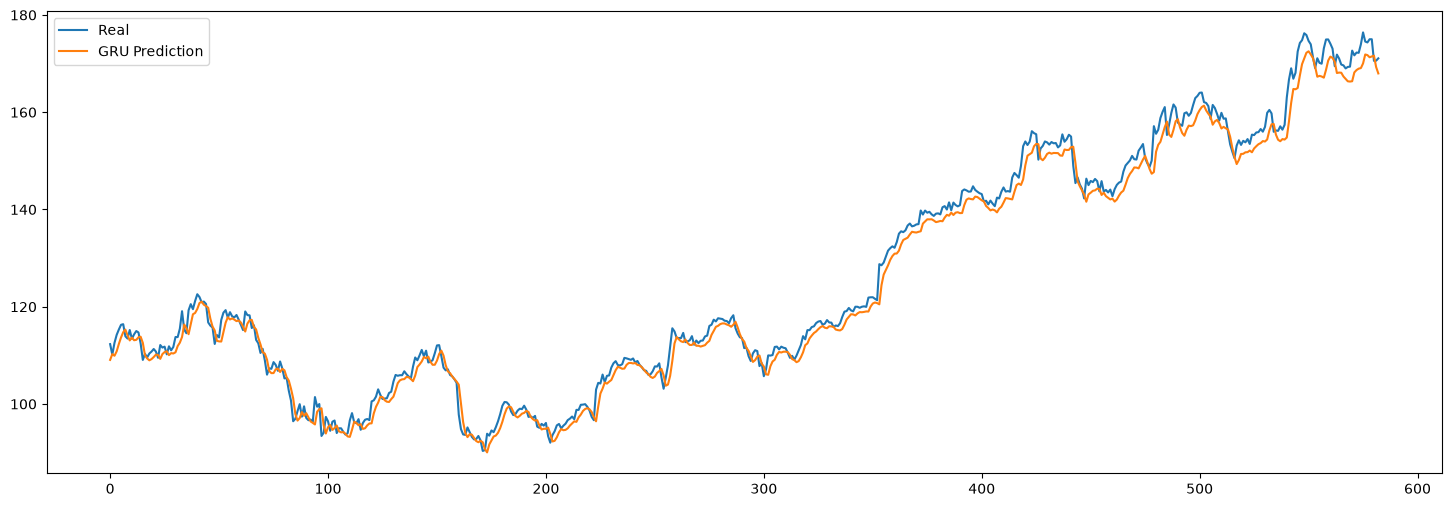

In [103]:
plt.figure(figsize=(18,6))

plt.plot(gru_actual,label="Real")

plt.plot(gru_predictions,label="GRU Prediction")

plt.legend()

plt.show()

In [104]:
torch.save(
    gru_model.state_dict(),
    "../models/gru_model.pth"
)

In [105]:
print("LSTM")

print("MSE :",mse)

print("RMSE :",rmse)

print()

print("GRU")

print("MSE :",gru_mse)

print("RMSE :",gru_rmse)

LSTM
MSE : 15.171350479125977
RMSE : 3.8950417814352103

GRU
MSE : 6.058772563934326
RMSE : 2.4614574064838752


In [106]:
results = pd.DataFrame({

    "Model":["LSTM","GRU"],

    "MSE":[mse,gru_mse],

    "RMSE":[rmse,gru_rmse]

})

results

,Model,MSE,RMSE
0,LSTM,15.171350,3.895042
1,GRU,6.058773,2.461457


In [107]:
results.to_csv(
    "../results/model_results.csv",
    index=False
)

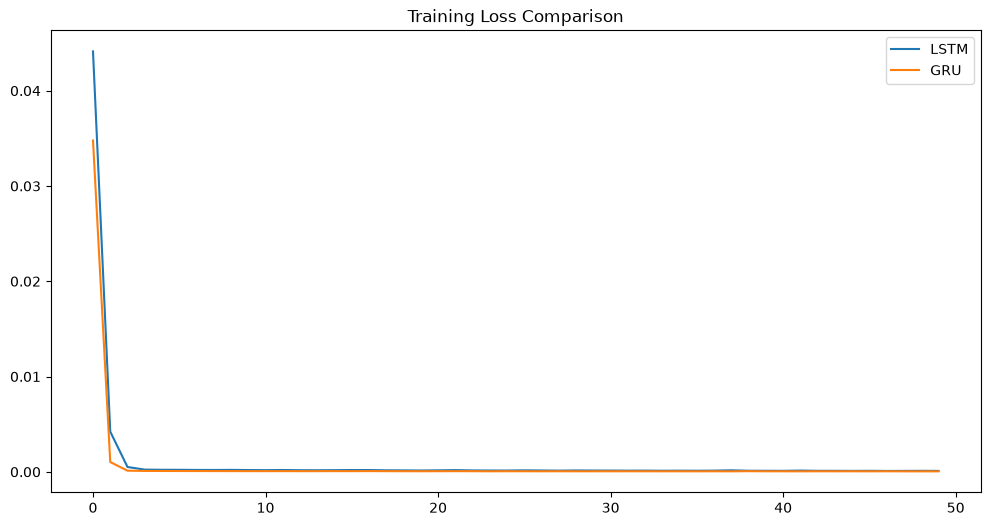

In [108]:
plt.figure(figsize=(12,6))

plt.plot(train_losses,label="LSTM")

plt.plot(gru_losses,label="GRU")

plt.legend()

plt.title("Training Loss Comparison")

plt.show()

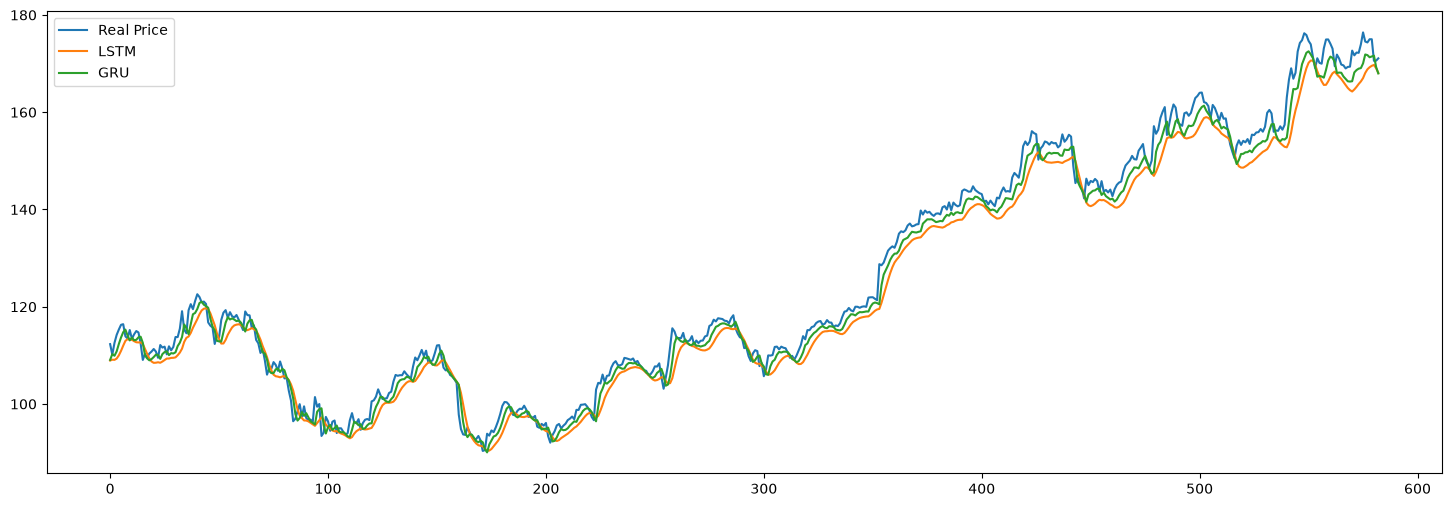

In [109]:
plt.figure(figsize=(18,6))

plt.plot(actuals,label="Real Price")

plt.plot(predictions,label="LSTM")

plt.plot(gru_predictions,label="GRU")

plt.legend()

plt.show()